In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gpjax as gpx
import pickle
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from gpjax.kernels import RBF, Linear, Periodic

from gallifrey.kernels import OrnsteinUhlenbeck
from gallifrey.kernelsearch import KernelSearch, describe_kernel
from gallifrey.util import calculate_example_lightcurve

In [3]:
plt.style.use("../figures/gpjax.mplstyle")
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

# CREATE ARTIFICAL DATA

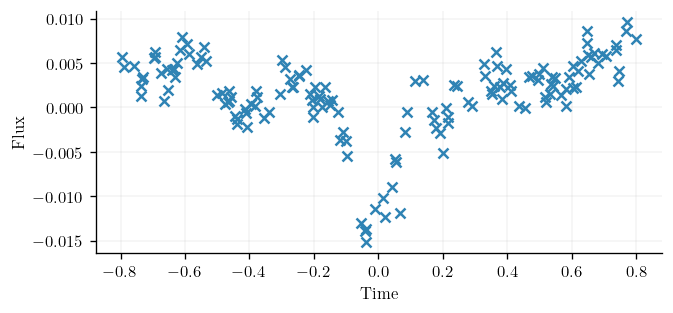

In [4]:
white_noise_std = 0.001
phi = 0.8
(
    t_train,
    lc_train,
    train_mask,
    t,
    lightcurve,
    systematics,
    noise,
    mask,
) = calculate_example_lightcurve(noise_std=white_noise_std, phi=phi)

noise_std = white_noise_std / jnp.sqrt(1 - phi**2)

plt.scatter(t_train, lc_train)
plt.ylabel("Flux")
plt.xlabel("Time")
plt.savefig("../figures/001_kernelsearch/test_data_ar_noise.pdf")

## PERFORM KERNEL SEARCH

In [15]:
kernel_library = [
    Linear(),
    RBF(),
    OrnsteinUhlenbeck(),
    Periodic(),
    # PoweredExponential(power=jnp.array(0.8)),
]  # default powered exponential has infinite parameter for some reason

In [16]:
tree = KernelSearch(
    kernel_library,
    X=jnp.array(t_train[train_mask]),
    y=jnp.array(lc_train[train_mask]),
    obs_stddev=noise_std,
    verbosity=1,
)

model = tree.search(
    depth=7,
    n_leafs=4,
    patience=1,
)

Fitting Layer 1: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it]

Layer 1 || Current top AICs: [-1312.8507830771996]
Terminated on layer: 1.
Final log likelihood: 659.4253915385998
Final number of model parameter: 3


In [17]:
model_name = "gpmodel__kernel"
with open(f"../data/processed/toy_data/gp_models/{model_name}", "wb") as file:
    pickle.dump(model, file)
describe_kernel(model)

'Periodic'

## PLOT GP PREDICTION

In [8]:
# calculate mean and std of predictive distribution
latent_dist = model(t.reshape(-1, 1), train_data=tree.data)
predictive_dist = model.likelihood(latent_dist)

predictive_mean = predictive_dist.mean()
predictive_std = predictive_dist.stddev()

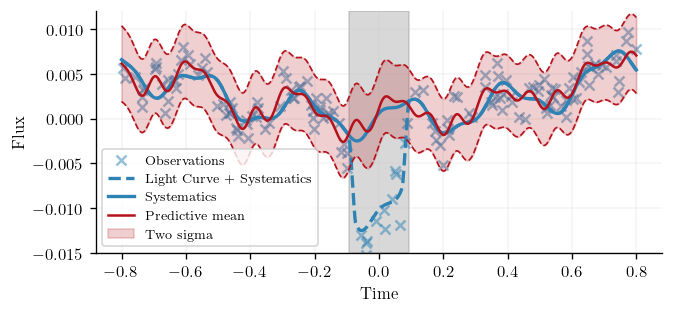

In [9]:
fig, ax = plt.subplots()
ax.scatter(t_train, lc_train, label="Observations", color=cols[0], alpha=0.5)
ax.plot(
    t,
    lightcurve + systematics,
    label="Light Curve + Systematics",
    color=cols[0],
    linestyle="--",
    linewidth=2,
)
ax.plot(
    t,
    systematics,
    label="Systematics",
    color=cols[0],
    linestyle="-",
    linewidth=2,
)

ax.plot(
    t,
    predictive_mean,
    label="Predictive mean",
    color=cols[1],
)
ax.fill_between(
    t,
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    label="Two sigma",
    color=cols[1],
)
ax.plot(
    t,
    predictive_mean - 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    t,
    predictive_mean + 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)

ax.fill_between(
    t,
    -0.015,
    0.012,
    where=~mask,
    alpha=0.3,
    color="grey",
    zorder=0,
)
ax.set_ylim([-0.015, 0.012])
ax.set_ylabel("Flux")
ax.set_xlabel("Time")

ax.legend(loc="center left", bbox_to_anchor=(0, 0.23))
plt.savefig("../figures/001_kernelsearch/gp_fit.pdf")

## PLOT KERNEL CONTRIBUTIONS

In [10]:
model2 = model.likelihood * gpx.gps.Prior(
    mean_function=model.prior.mean_function,
    kernel=model.prior.kernel.kernels[0],  # type: ignore
)
model3 = model.likelihood * gpx.gps.Prior(
    mean_function=model.prior.mean_function,
    kernel=model.prior.kernel.kernels[1],  # type: ignore
)

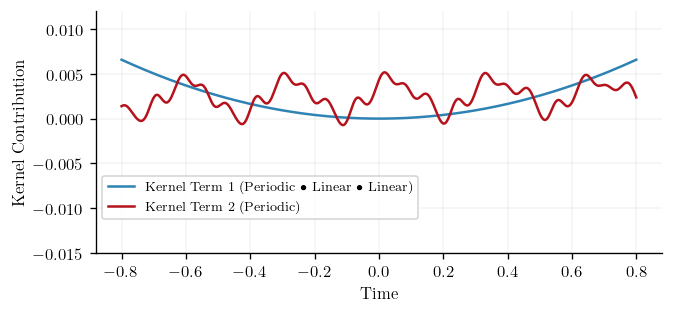

In [11]:
latent_dist2 = model2(t.reshape(-1, 1), train_data=tree.data)
predictive_dist2 = model2.likelihood(latent_dist2)
predictive_mean2 = predictive_dist2.mean()

latent_dist3 = model3(t.reshape(-1, 1), train_data=tree.data)
predictive_dist3 = model3.likelihood(latent_dist3)
predictive_mean3 = predictive_dist3.mean()

fig, ax = plt.subplots()

ax.plot(
    t,
    predictive_mean2,
    label="Kernel Term 1 (Periodic • Linear • Linear)",
    color=cols[0],
)

ax.plot(
    t,
    predictive_mean3,
    label="Kernel Term 2 (Periodic)",
    color=cols[1],
)

ax.set_ylim([-0.015, 0.012])
ax.set_ylabel("Kernel Contribution")
ax.set_xlabel("Time")

ax.legend(loc="center left", bbox_to_anchor=(0, 0.23))
plt.savefig("../figures/001_kernelsearch/gp_fit_decompostion.pdf")